# Feature Engineering and Baseline Models

**Thesis:** *Evaluation of Performer Quality and Segmentation of Results in Crowdsourcing Systems*

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_validate, GridSearchCV, train_test_split
)
from sklearn.inspection import permutation_importance

# Optional gradient-boosting baseline — LightGBM is the standard production
# reference for tabular problems; fall back to sklearn if unavailable.
try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    HAVE_LGBM = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as LGBMClassifier
    from sklearn.ensemble import GradientBoostingRegressor as LGBMRegressor
    HAVE_LGBM = False
    print("LightGBM not available — falling back to sklearn GradientBoosting.")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D9D9D9",
    "axes.grid": True,
    "grid.color": "#ECECEC",
    "grid.linewidth": 0.6,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
    "figure.dpi": 130,
})

C = {
    "blue": "#4C78A8",
    "teal": "#2A9D8F",
    "green": "#59A14F",
    "orange": "#F28E2B",
    "red": "#E15759",
    "purple": "#9C6ADE",
    "gray": "#7A7A7A",
}

## 1. Data loading and preprocessing

In [2]:
def load_data(path="data.csv"):
    candidates = [Path(path), Path("sample_data.csv"), Path("/mnt/data/sample_data.csv")]
    for candidate in candidates:
        if candidate.exists():
            df = pd.read_csv(candidate)
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])
            print(f"Loaded: {candidate} | rows={len(df):,}")
            return df
    raise FileNotFoundError("data.csv not found. Put the dataset next to the notebook or keep sample_data.csv.")

def prepare_base(df):
    df = df.copy()

    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
    df["finished_at"] = pd.to_datetime(df["finished_at"], errors="coerce")

    df["is_error_report"] = df["user_ans"].eq(3)
    df = df[~df["is_error_report"]].copy()

    df["answered"] = df["user_ans"].notna()
    df["duration_sec"] = (df["finished_at"] - df["created_at"]).dt.total_seconds()
    df["per_task_sec"] = df["duration_sec"] / df["tasks_per_page"].replace(0, np.nan)

    df["is_gold_task"] = df["task_type"].eq(1)
    df["is_training_task"] = df["task_type"].eq(2)
    df["is_regular_task"] = df["task_type"].eq(0)

    df["is_regular_pool"] = df["pool_type"].eq(0)
    df["is_rehab_pool"] = df["pool_type"].eq(1)
    df["is_training_pool"] = df["pool_type"].eq(3)

    df["valid_target_label"] = df["task_ans"].notna() & df["task_ans"].ne(3)

    df["agreement_proxy"] = np.where(
        df["answered"] & df["valid_target_label"],
        (df["user_ans"] == df["task_ans"]).astype(float),
        np.nan,
    )

    df["gold_correct"] = np.where(
        df["is_gold_task"] & df["answered"] & df["valid_target_label"],
        (df["user_ans"] == df["task_ans"]).astype(float),
        np.nan,
    )

    df["hour"] = df["created_at"].dt.hour
    df["dayofweek"] = df["created_at"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    return df

def safe_entropy(values):
    values = pd.Series(values).dropna()
    if values.empty:
        return np.nan
    p = values.value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())

def top_share(values):
    values = pd.Series(values).dropna()
    if values.empty:
        return np.nan
    return float(values.value_counts(normalize=True).iloc[0])

def longest_run(series, value):
    best = 0
    cur = 0
    for x in pd.Series(series).fillna(-1):
        if x == value:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

def add_worker_split(df, history_share=0.80):
    df = df.sort_values(["ozon_id", "created_at", "task_id"]).copy()
    df["worker_row"] = df.groupby("ozon_id").cumcount()
    df["worker_n"] = df.groupby("ozon_id")["task_id"].transform("size")
    split_point = np.maximum(1, np.floor(df["worker_n"] * history_share)).astype(int)
    df["is_history"] = df["worker_row"] < split_point
    return df

def build_worker_features(frame):
    frame = frame.sort_values(["ozon_id", "created_at", "task_id"]).copy()

    activity = frame.groupby("ozon_id").agg(
        n_rows=("task_id", "size"),
        n_answers=("answered", "sum"),
        n_tasks=("task_id", "nunique"),
        n_pages=("page_id", "nunique"),
        n_projects=("project_id", "nunique"),
        n_pools=("pool_id", "nunique"),
        active_days=("created_at", lambda s: s.dt.date.nunique()),
        span_days=("created_at", lambda s: max((s.max() - s.min()).days + 1, 1)),
        skip_rate=("skipped", "mean"),
        tasks_per_page_mean=("tasks_per_page", "mean"),
        overlap_mean=("overlap", "mean"),
        overlap_std=("overlap", "std"),
        price_mean=("price", "mean"),
        share_gold_tasks=("is_gold_task", "mean"),
        share_rehab_pools=("is_rehab_pool", "mean"),
    )

    gold = frame[frame["is_gold_task"] & frame["answered"] & frame["valid_target_label"]].copy()
    if len(gold):
        gold["gold_order"] = gold.groupby("ozon_id").cumcount()
        gold["gold_n"] = gold.groupby("ozon_id")["task_id"].transform("size")
        gold["from_end"] = gold["gold_n"] - gold["gold_order"]

        gold_summary = gold.groupby("ozon_id").agg(
            n_gold=("task_id", "size"),
            gold_acc=("gold_correct", "mean"),
            gold_acc_std=("gold_correct", "std"),
            gold_longest_success_streak=("gold_correct", lambda s: longest_run(s, 1.0)),
            gold_longest_error_streak=("gold_correct", lambda s: longest_run(s, 0.0)),
        )

        gold_recent5 = gold[gold["from_end"] <= 5].groupby("ozon_id")["gold_correct"].mean().rename("gold_recent5_acc")
        gold_recent10 = gold[gold["from_end"] <= 10].groupby("ozon_id")["gold_correct"].mean().rename("gold_recent10_acc")
        gold_first5 = gold[gold["gold_order"] < 5].groupby("ozon_id")["gold_correct"].mean().rename("gold_first5_acc")

        class_gap = gold[gold["user_ans"].isin([1, 2, 4])].pivot_table(
            index="ozon_id",
            columns="user_ans",
            values="gold_correct",
            aggfunc="mean"
        )
        if len(class_gap.columns) >= 2:
            class_gap["gold_class_gap"] = class_gap.max(axis=1) - class_gap.min(axis=1)
            class_gap = class_gap[["gold_class_gap"]]
        else:
            class_gap = pd.DataFrame(index=gold_summary.index)

        gold_features = pd.concat([gold_summary, gold_recent5, gold_recent10, gold_first5, class_gap], axis=1)
        gold_features["gold_learning_delta"] = gold_features["gold_recent10_acc"] - gold_features["gold_first5_acc"]
    else:
        gold_features = pd.DataFrame(index=activity.index)

    regular = frame[
        frame["is_regular_pool"] &
        frame["is_regular_task"] &
        frame["answered"] &
        frame["valid_target_label"]
    ].copy()

    if len(regular):
        regular_features = regular.groupby("ozon_id").agg(
            n_regular=("task_id", "size"),
            reg_agreement_proxy=("agreement_proxy", "mean"),
            reg_agreement_std=("agreement_proxy", "std"),
            regular_answer_entropy=("user_ans", safe_entropy),
            regular_answer_mode_share=("user_ans", top_share),
        )
    else:
        regular_features = pd.DataFrame(index=activity.index)

    timed = frame[frame["per_task_sec"].between(1, 600)].copy()
    if len(timed):
        speed = timed.groupby("ozon_id").agg(
            per_task_sec_median=("per_task_sec", "median"),
            per_task_sec_mean=("per_task_sec", "mean"),
            per_task_sec_std=("per_task_sec", "std"),
            fast_task_share=("per_task_sec", lambda s: (s < 5).mean()),
            slow_task_share=("per_task_sec", lambda s: (s > 30).mean()),
            mean_hour=("hour", "mean"),
            weekend_share=("is_weekend", "mean"),
        )
    else:
        speed = pd.DataFrame(index=activity.index)

    answered = frame[frame["answered"]].copy()
    if len(answered):
        behaviour = answered.groupby("ozon_id").agg(
            answer_entropy=("user_ans", safe_entropy),
            answer_mode_share=("user_ans", top_share),
            main_project_share=("project_id", top_share),
            pct_label_1=("user_ans", lambda s: (s == 1).mean()),
        )
    else:
        behaviour = pd.DataFrame(index=activity.index)

    feat = activity.join([gold_features, regular_features, speed, behaviour], how="left").reset_index()

    feat["answers_per_active_day"] = feat["n_answers"] / feat["active_days"].replace(0, np.nan)
    feat["answers_per_span_day"] = feat["n_answers"] / feat["span_days"].replace(0, np.nan)
    feat["gold_share_among_answers"] = feat["n_gold"] / feat["n_answers"].replace(0, np.nan)

    return feat

In [3]:
df_raw = load_data("data.csv")

preprocessing_stats = pd.DataFrame({
    "metric": [
        "total rows",
        "rows with user_ans = 3",
        "rows with task_ans = 3",
    ],
    "value": [
        len(df_raw),
        int(df_raw["user_ans"].eq(3).sum()),
        int(df_raw["task_ans"].eq(3).sum()),
    ]
})

df = prepare_base(df_raw)
preprocessing_stats

Loaded: data.csv | rows=4,120,698


,metric,value
0,total rows,4120698
1,rows with user_ans = 3,14964
2,rows with task_ans = 3,804


Answers with label `3` are excluded before feature construction because this label is used when a worker reports an error in the task and does not belong to the main target label space. Rows with `task_ans = 3` are kept in the dataset for activity statistics, but they are excluded from quality-related features and targets.

## 2. Validation design

In [4]:
df = add_worker_split(df, history_share=0.80)

history_df = df[df["is_history"]].copy()
holdout_df = df[~df["is_history"]].copy()

split_overview = pd.DataFrame({
    "table": ["history", "holdout"],
    "rows": [len(history_df), len(holdout_df)],
    "workers": [history_df["ozon_id"].nunique(), holdout_df["ozon_id"].nunique()],
})
split_overview

,table,rows,workers
0,history,3280781,14359
1,holdout,824953,12706


The feature table is built only on the historical 80% of each worker's timeline. The target is evaluated on the future 20% of gold-task observations. This chronological split reduces leakage and makes the baseline closer to the real scoring scenario.

## 3. Worker-level feature table

In [5]:
worker_features_history = build_worker_features(history_df)
worker_features_full = build_worker_features(df)

feature_groups = pd.DataFrame({
    "group": ["activity", "gold history", "regular-task proxy", "speed", "behaviour"],
    "examples": [
        "n_answers, n_projects, active_days, skip_rate",
        "gold_acc, recent gold accuracy, streaks, learning_delta",
        "reg_agreement_proxy, reg_agreement_std",
        "per_task_sec_median, fast_task_share, slow_task_share",
        "answer_entropy, answer_mode_share, main_project_share",
    ]
})
feature_groups

,group,examples
0,activity,"n_answers, n_projects, active_days, skip_rate"
1,gold history,"gold_acc, recent gold accuracy, streaks, learn..."
2,regular-task proxy,"reg_agreement_proxy, reg_agreement_std"
3,speed,"per_task_sec_median, fast_task_share, slow_tas..."
4,behaviour,"answer_entropy, answer_mode_share, main_projec..."


In [6]:
feature_overview = pd.DataFrame({
    "table": ["worker_features_history", "worker_features_full"],
    "rows": [len(worker_features_history), len(worker_features_full)],
    "columns": [worker_features_history.shape[1], worker_features_full.shape[1]],
})
feature_overview

,table,rows,columns
0,worker_features_history,14359,44
1,worker_features_full,14359,44


In [7]:
missing_share = (
    worker_features_history.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)

missing_share[missing_share["missing_share"] > 0].head(15)

,missing_share
gold_acc_std,0.923254
gold_recent10_acc,0.918100
n_gold,0.918100
gold_learning_delta,0.918100
gold_class_gap,0.918100
gold_first5_acc,0.918100
gold_recent5_acc,0.918100
gold_longest_error_streak,0.918100
gold_longest_success_streak,0.918100
gold_acc,0.918100


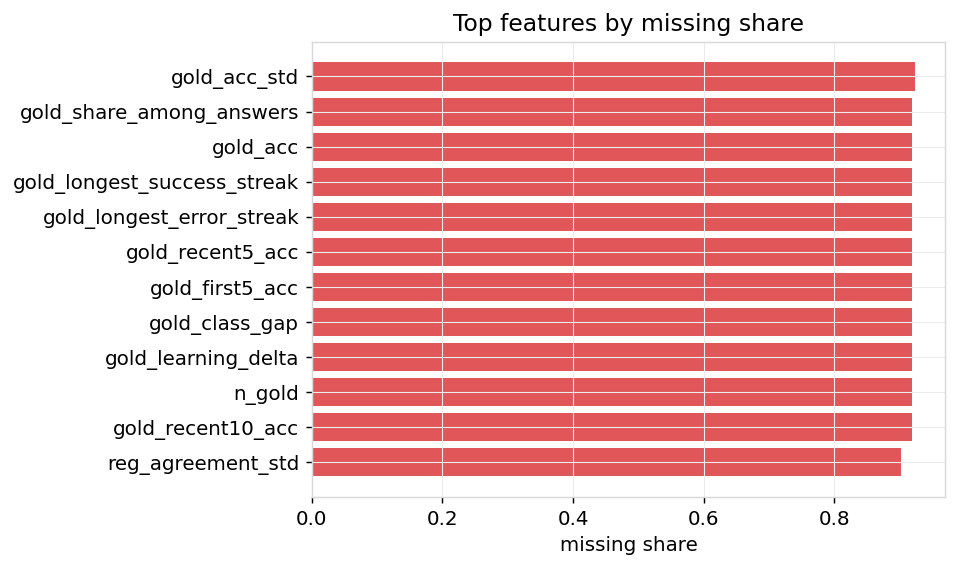

In [8]:
top_missing = missing_share[missing_share["missing_share"] > 0].head(12).sort_values("missing_share")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(top_missing.index, top_missing["missing_share"], color=C["red"])
ax.set_title("Top features by missing share")
ax.set_xlabel("missing share")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

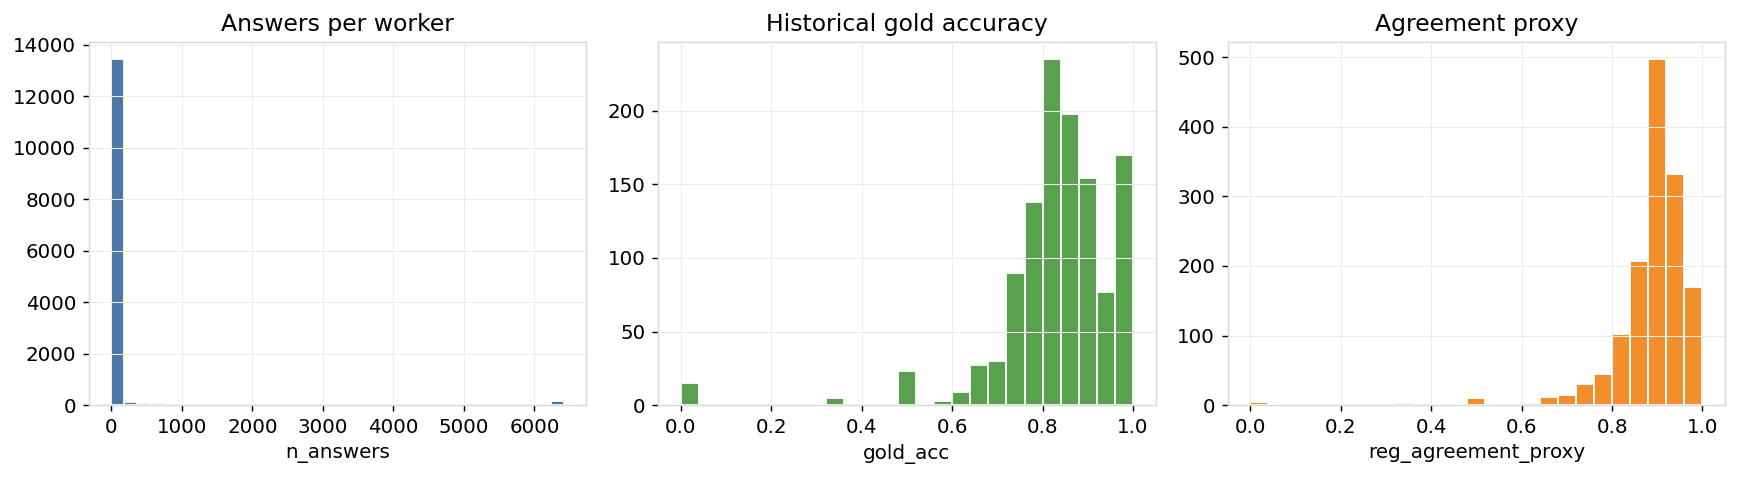

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

worker_features_history["n_answers"].clip(upper=worker_features_history["n_answers"].quantile(0.99)).hist(
    bins=35, ax=axes[0], color=C["blue"], edgecolor="white"
)
axes[0].set_title("Answers per worker")
axes[0].set_xlabel("n_answers")

worker_features_history["gold_acc"].dropna().hist(
    bins=25, ax=axes[1], color=C["green"], edgecolor="white"
)
axes[1].set_title("Historical gold accuracy")
axes[1].set_xlabel("gold_acc")

worker_features_history["reg_agreement_proxy"].dropna().hist(
    bins=25, ax=axes[2], color=C["orange"], edgecolor="white"
)
axes[2].set_title("Agreement proxy")
axes[2].set_xlabel("reg_agreement_proxy")

plt.tight_layout()
plt.show()

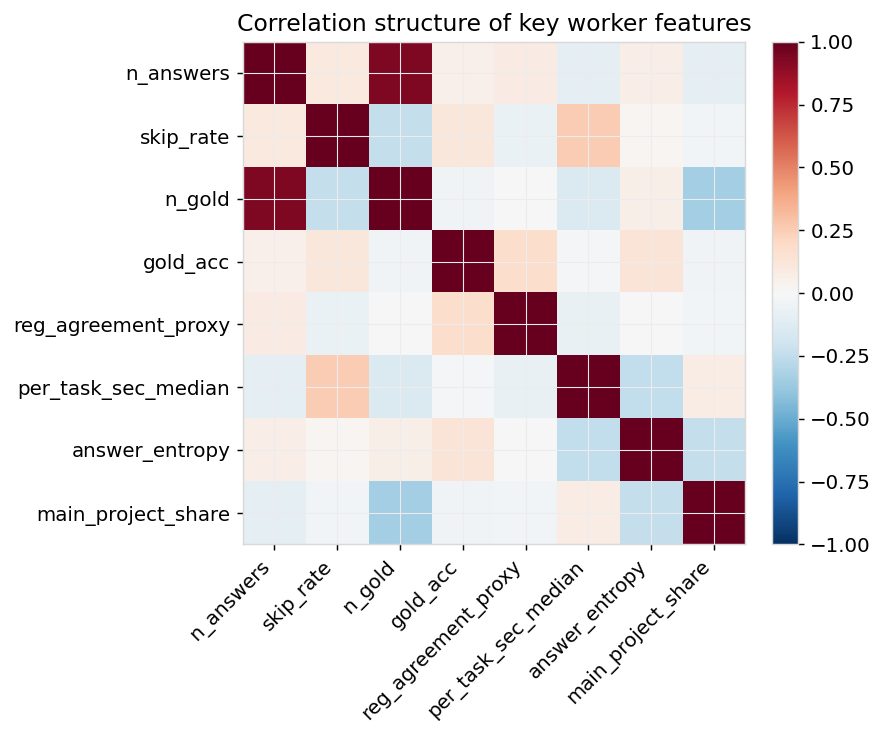

In [10]:
preview_features = [
    "n_answers",
    "skip_rate",
    "n_gold",
    "gold_acc",
    "reg_agreement_proxy",
    "per_task_sec_median",
    "answer_entropy",
    "main_project_share",
]
preview_features = [c for c in preview_features if c in worker_features_history.columns]

corr = worker_features_history[preview_features].corr()

fig, ax = plt.subplots(figsize=(7.2, 5.8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(preview_features)))
ax.set_xticklabels(preview_features, rotation=45, ha="right")
ax.set_yticks(range(len(preview_features)))
ax.set_yticklabels(preview_features)
ax.set_title("Correlation structure of key worker features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

The feature table combines direct quality signals from gold tasks and indirect proxy signals from regular production tasks. The proxy features are useful, but they should not be interpreted as true accuracy.

## 4. Target construction

In [11]:
holdout_gold = holdout_df[
    holdout_df["is_gold_task"] &
    holdout_df["answered"] &
    holdout_df["valid_target_label"]
].copy()

worker_targets = holdout_gold.groupby("ozon_id").agg(
    future_n_gold=("task_id", "size"),
    future_gold_acc=("gold_correct", "mean"),
).reset_index()

worker_targets["future_high_quality"] = (
    (worker_targets["future_gold_acc"] >= 0.85) &
    (worker_targets["future_n_gold"] >= 5)
).astype(int)

worker_model_data = worker_features_history.merge(worker_targets, on="ozon_id", how="left")

target_overview = pd.DataFrame({
    "metric": [
        "workers with future gold observations",
        "median future_n_gold",
        "share of future_high_quality = 1",
    ],
    "value": [
        int(worker_targets["ozon_id"].nunique()),
        round(worker_targets["future_n_gold"].median(), 2),
        round(worker_targets["future_high_quality"].mean(), 4),
    ]
})
target_overview

,metric,value
0,workers with future gold observations,1032.0000
1,median future_n_gold,28.0000
2,share of future_high_quality = 1,0.3547


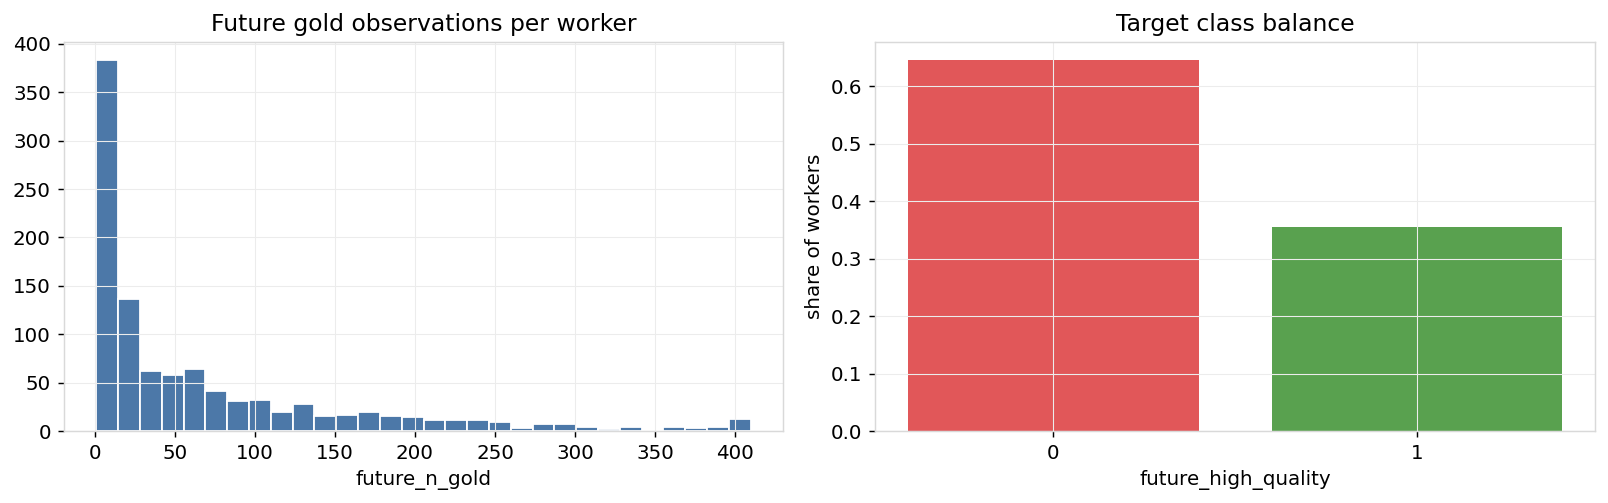

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

worker_targets["future_n_gold"].clip(upper=worker_targets["future_n_gold"].quantile(0.99)).hist(
    bins=30, ax=axes[0], color=C["blue"], edgecolor="white"
)
axes[0].set_title("Future gold observations per worker")
axes[0].set_xlabel("future_n_gold")

class_share = worker_targets["future_high_quality"].value_counts(normalize=True).sort_index()
axes[1].bar(
    [str(int(x)) for x in class_share.index],
    class_share.values,
    color=[C["red"], C["green"]][:len(class_share)],
)
axes[1].set_title("Target class balance")
axes[1].set_xlabel("future_high_quality")
axes[1].set_ylabel("share of workers")

plt.tight_layout()
plt.show()

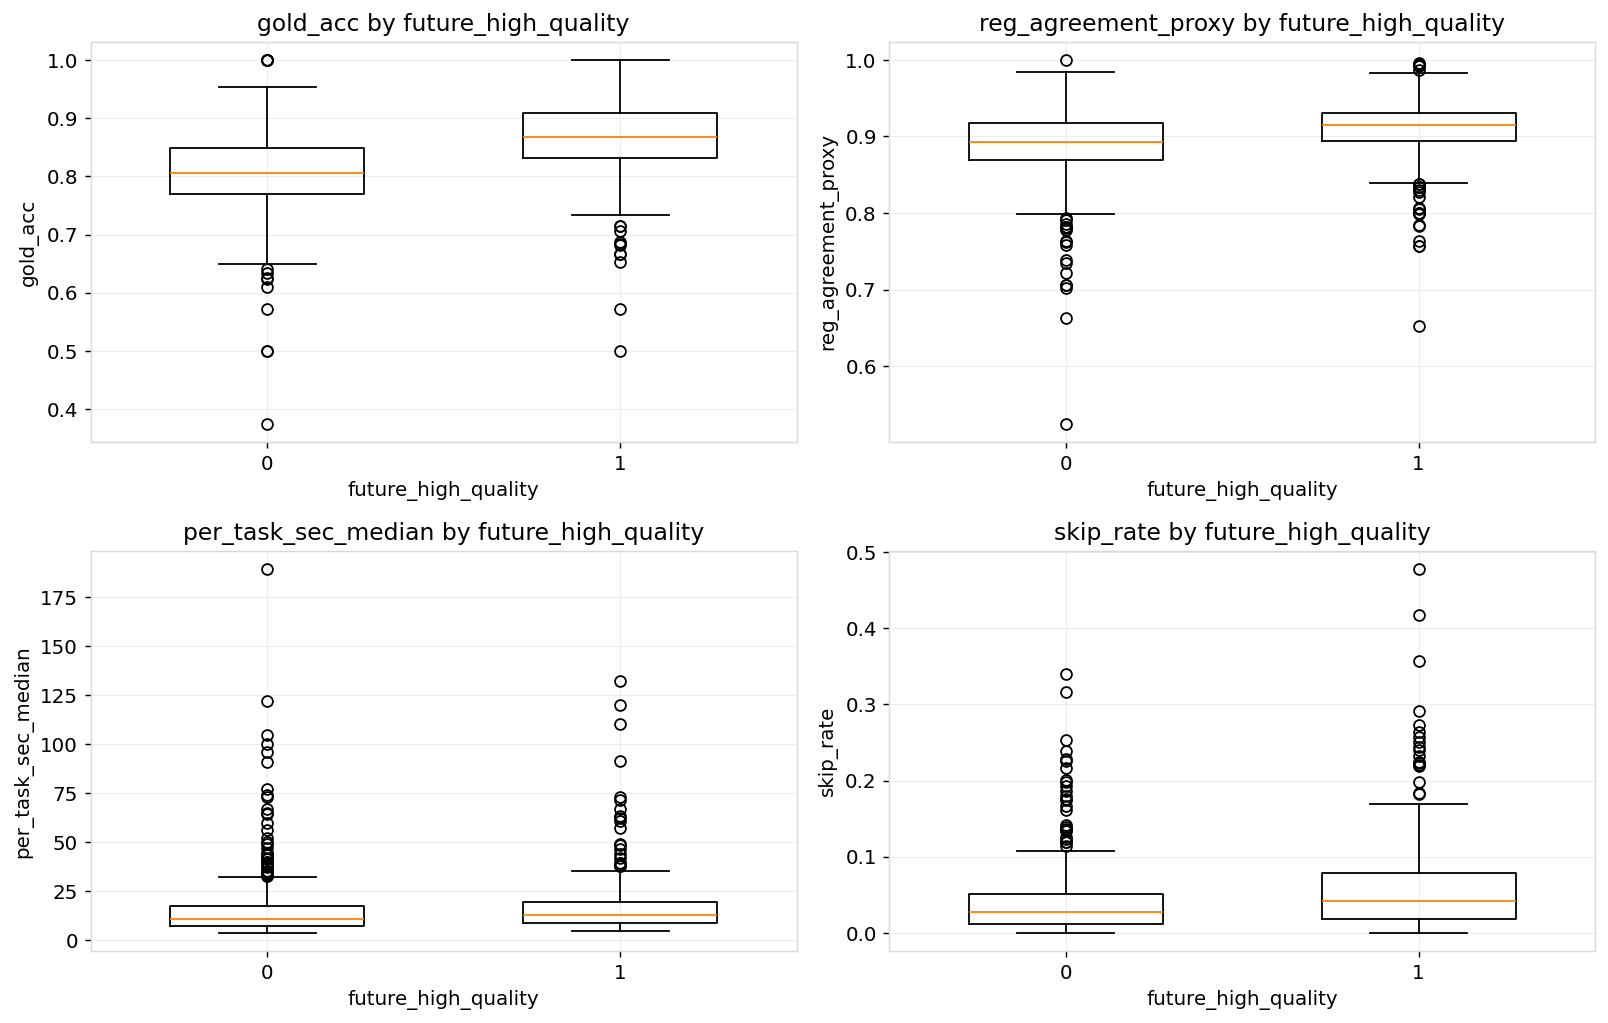

In [13]:
eligible_preview = worker_model_data[
    worker_model_data["future_n_gold"].ge(5) &
    worker_model_data["n_answers"].ge(20) &
    worker_model_data["future_gold_acc"].notna()
].copy()

feature_view = [
    "gold_acc",
    "reg_agreement_proxy",
    "per_task_sec_median",
    "skip_rate",
]
feature_view = [c for c in feature_view if c in eligible_preview.columns]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8))
axes = axes.flatten()

for ax, col in zip(axes, feature_view):
    groups = [
        eligible_preview.loc[eligible_preview["future_high_quality"] == 0, col].dropna(),
        eligible_preview.loc[eligible_preview["future_high_quality"] == 1, col].dropna(),
    ]
    ax.boxplot(groups, labels=["0", "1"], widths=0.55)
    ax.set_title(f"{col} by future_high_quality")
    ax.set_xlabel("future_high_quality")
    ax.set_ylabel(col)

for ax in axes[len(feature_view):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

The main baseline task is to predict whether a worker will remain high-quality in the future. A worker is assigned to the positive class if their future gold accuracy is at least `0.85` and they have at least `5` future gold-task observations.

## 5. Baseline models

In [14]:
selected_features = [
    "n_answers",
    "n_projects",
    "active_days",
    "skip_rate",
    "n_gold",
    "gold_acc",
    "gold_recent5_acc",
    "gold_recent10_acc",
    "gold_learning_delta",
    "reg_agreement_proxy",
    "per_task_sec_median",
    "per_task_sec_std",
    "answer_entropy",
    "answer_mode_share",
    "main_project_share",
    "overlap_mean",
]
selected_features = [c for c in selected_features if c in worker_model_data.columns]

eligible = worker_model_data[
    worker_model_data["future_n_gold"].ge(5) &
    worker_model_data["n_answers"].ge(20) &
    worker_model_data["future_gold_acc"].notna()
].copy()

X_all = eligible[selected_features]
y = eligible["future_high_quality"]
y_reg = eligible["future_gold_acc"]

class_counts = y.value_counts()
n_splits = int(min(5, class_counts.min())) if len(class_counts) > 1 else 3
n_splits = max(n_splits, 3)

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=n_splits, shuffle=True, random_state=42)

logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=3,
        random_state=42,
        class_weight="balanced",
    )),
])

# Gradient-boosting baseline — the standard reference for tabular problems.
if HAVE_LGBM:
    lgbm_clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", LGBMClassifier(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=10,
            class_weight="balanced",
            random_state=42,
            verbose=-1,
        )),
    ])
else:
    lgbm_clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", LGBMClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
        )),
    ])

In [15]:
model_specs = [
    ("gold_acc only", logreg, ["gold_acc"]),
    ("agreement proxy only", logreg, ["reg_agreement_proxy"]),
    ("combined logistic regression", logreg, selected_features),
    ("combined random forest", rf, selected_features),
    ("combined gradient boosting", lgbm_clf, selected_features),
]

rows = []
for name, model, feats in model_specs:
    scores = cross_validate(
        model,
        eligible[feats],
        y,
        cv=cv,
        scoring=["roc_auc", "average_precision", "f1"],
        n_jobs=None,
    )
    rows.append({
        "model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_average_precision"].mean(),
        "F1": scores["test_f1"].mean(),
    })

baseline_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
baseline_results

,model,ROC-AUC,PR-AUC,F1
3,combined random forest,0.778780,0.748184,0.684841
2,combined logistic regression,0.765796,0.735429,0.680516
0,gold_acc only,0.752956,0.711631,0.684439
1,agreement proxy only,0.662668,0.613031,0.635388


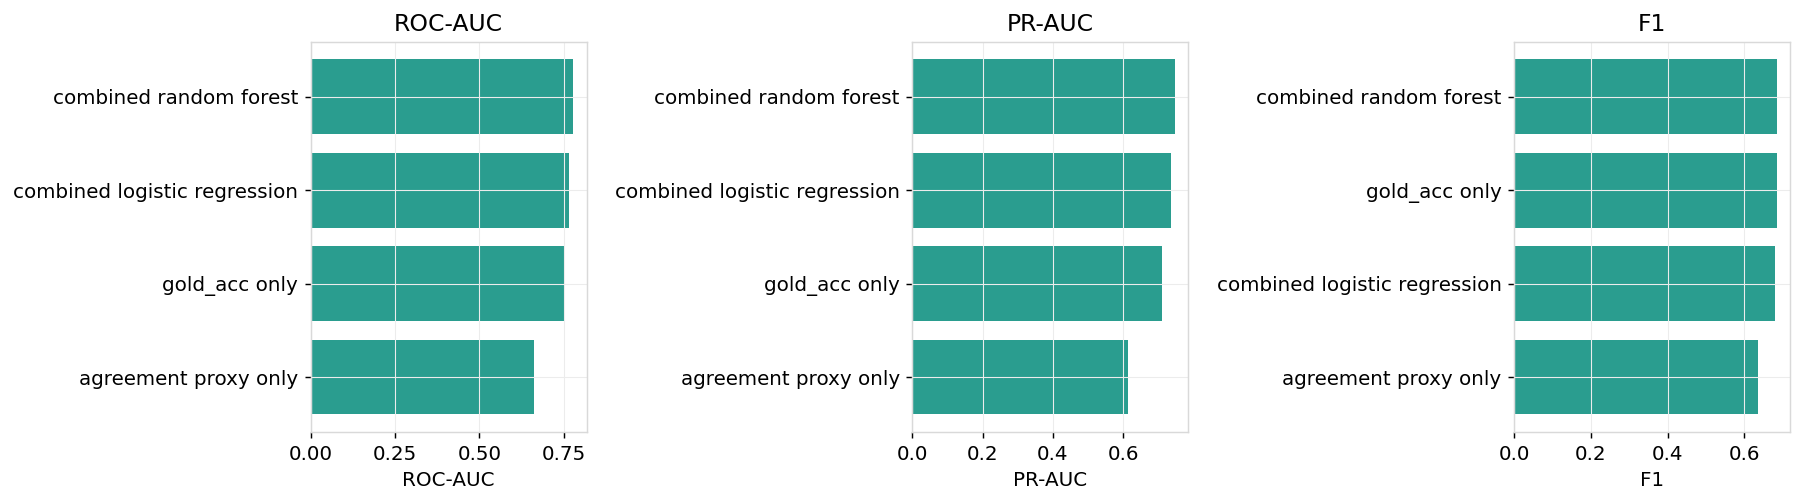

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC", "F1"]):
    tmp = baseline_results.sort_values(metric)
    ax.barh(tmp["model"], tmp[metric], color=C["teal"])
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

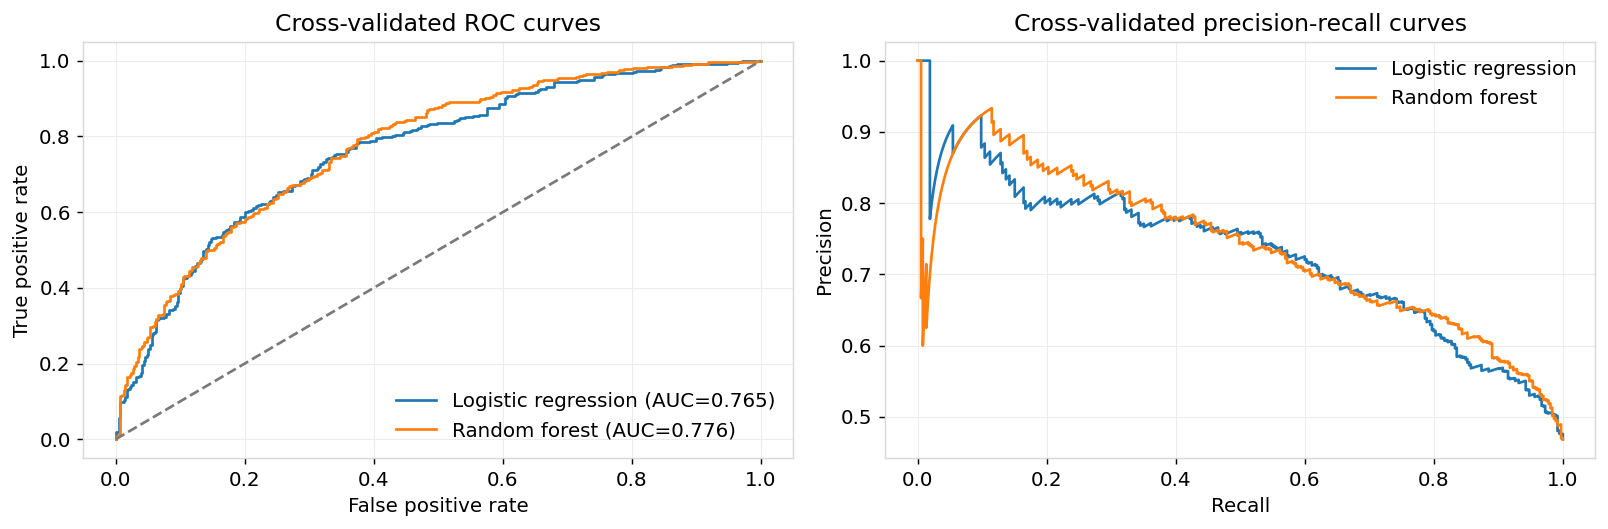

In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, precision_recall_curve, auc

oof_models = {
    "Logistic regression": logreg,
    "Random forest": rf,
    "Gradient boosting": lgbm_clf,
}

oof_pred = {}
for name, model in oof_models.items():
    oof_pred[name] = cross_val_predict(
        model,
        X_all,
        y,
        cv=cv,
        method="predict_proba",
    )[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

for name, pred in oof_pred.items():
    fpr, tpr, _ = roc_curve(y, pred)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color=C["gray"])
axes[0].set_title("Cross-validated ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

for name, pred in oof_pred.items():
    precision, recall, _ = precision_recall_curve(y, pred)
    axes[1].plot(recall, precision, label=name)
axes[1].set_title("Cross-validated precision-recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

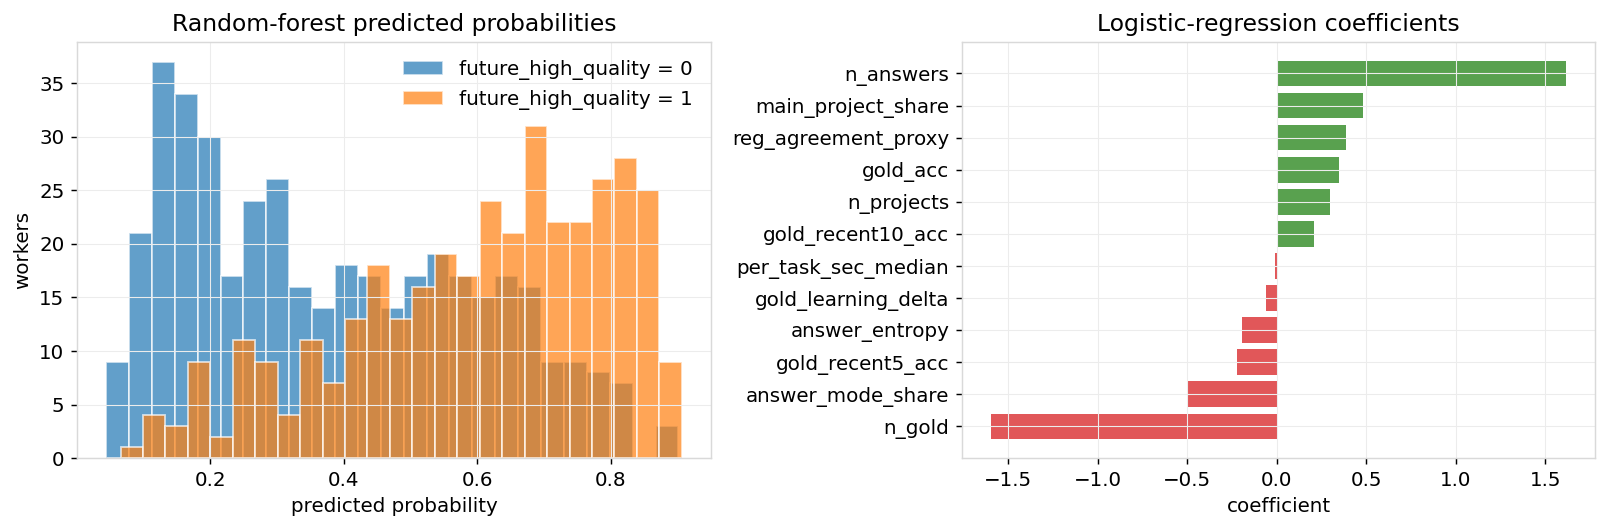

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].hist(oof_pred["Random forest"][y == 0], bins=25, alpha=0.7, label="future_high_quality = 0", edgecolor="white")
axes[0].hist(oof_pred["Random forest"][y == 1], bins=25, alpha=0.7, label="future_high_quality = 1", edgecolor="white")
axes[0].set_title("Random-forest predicted probabilities")
axes[0].set_xlabel("predicted probability")
axes[0].set_ylabel("workers")
axes[0].legend()

logreg.fit(X_all, y)
logreg_coef = pd.DataFrame({
    "feature": selected_features,
    "coef": logreg.named_steps["clf"].coef_[0],
}).sort_values("coef")

tmp = pd.concat([logreg_coef.head(6), logreg_coef.tail(6)])
axes[1].barh(tmp["feature"], tmp["coef"], color=[C["red"] if x < 0 else C["green"] for x in tmp["coef"]])
axes[1].set_title("Logistic-regression coefficients")
axes[1].set_xlabel("coefficient")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The purpose of the baseline comparison is not to build a final production model, but to verify that the engineered worker representation contains predictive information about future quality. For feature attribution we use **permutation importance** rather than impurity-based `feature_importances_`: the latter is biased towards high-cardinality and numeric features, whereas permutation importance measures the actual drop in out-of-sample AUC when a feature is shuffled.

In [19]:
# Permutation importance — unbiased alternative to RF's impurity-based
# feature_importances_. Computed on a held-out split with scoring on AUC drop.
X_train_pi, X_test_pi, y_train_pi, y_test_pi = train_test_split(
    X_all, y, test_size=0.30, random_state=42, stratify=y,
)

rf.fit(X_train_pi, y_train_pi)
perm_rf = permutation_importance(
    rf, X_test_pi, y_test_pi,
    n_repeats=15, random_state=42, scoring="roc_auc", n_jobs=None,
)
rf_importance = pd.DataFrame({
    "feature": selected_features,
    "importance_mean": perm_rf.importances_mean,
    "importance_std": perm_rf.importances_std,
}).sort_values("importance_mean", ascending=False)

rf_importance.head(12)

,feature,importance
5,gold_acc,0.218984
15,overlap_mean,0.160059
9,reg_agreement_proxy,0.097109
12,answer_entropy,0.066157
4,n_gold,0.057680
10,per_task_sec_median,0.055070
0,n_answers,0.053934
13,answer_mode_share,0.052888
11,per_task_sec_std,0.051455
3,skip_rate,0.050970


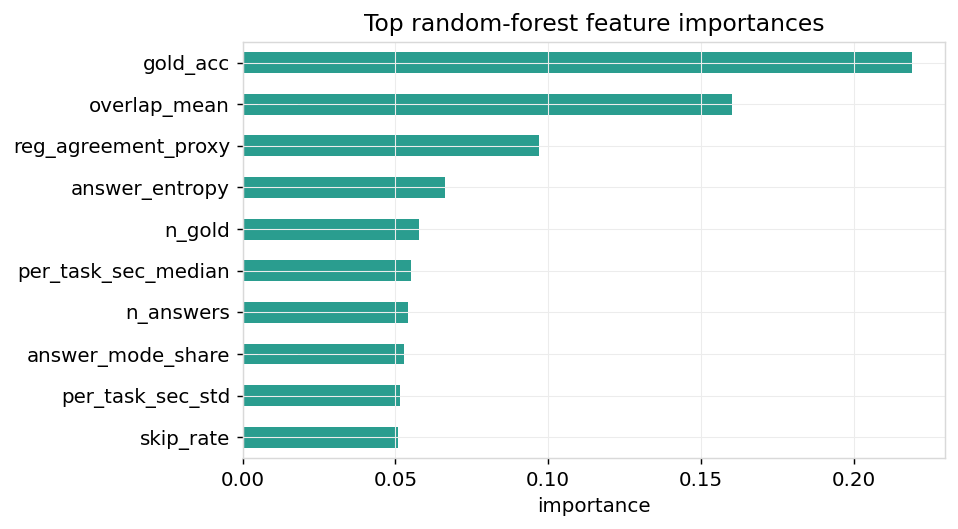

In [20]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
top = rf_importance.head(10).sort_values("importance_mean")
ax.barh(top["feature"], top["importance_mean"],
        xerr=top["importance_std"], color=C["teal"], ecolor=C["gray"], capsize=2)
ax.set_title("Random-forest permutation importance (AUC drop on held-out)")
ax.set_xlabel("mean AUC decrease when feature is shuffled")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 5.1 · Hyperparameter tuning

The baselines above use hand-picked hyperparameters — reasonable but not optimised. A small `GridSearchCV` over the gradient-boosting model shows how much headroom tuning buys us.

In [ ]:
# Hyperparameter tuning for the gradient-boosting baseline.
if HAVE_LGBM:
    param_grid = {
        "clf__n_estimators": [200, 400],
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__num_leaves": [15, 31, 63],
        "clf__min_child_samples": [5, 10, 20],
    }
else:
    param_grid = {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 4, 5],
        "clf__learning_rate": [0.05, 0.1],
    }

grid = GridSearchCV(
    lgbm_clf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=None,
    refit=True,
)
grid.fit(X_all, y)

baseline_gb_auc = baseline_results.loc[
    baseline_results["model"] == "combined gradient boosting", "ROC-AUC"
].iloc[0]

print(f"Best params:   {grid.best_params_}")
print(f"Best CV AUC:   {grid.best_score_:.4f}")
print(f"Baseline AUC:  {baseline_gb_auc:.4f}")
print(f"Tuning gain:   {grid.best_score_ - baseline_gb_auc:+.4f}")

tuned_lgbm = grid.best_estimator_

### 5.2 · Regression framing of the target

The classification target `future_high_quality` discretises future gold accuracy at `0.85`. That threshold is operationally meaningful but throws away information — a worker at 0.84 is operationally close to a worker at 0.86. The continuous target `future_gold_acc` preserves that information. Reporting both framings lets the reader see that the signal is present regardless of the threshold choice.

In [ ]:
# Regression framing — predict continuous future_gold_acc.
reg_rows = []

ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0)),
])
rf_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", RandomForestRegressor(
        n_estimators=400, max_depth=6, min_samples_leaf=3, random_state=42,
    )),
])
if HAVE_LGBM:
    lgbm_reg_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("reg", LGBMRegressor(
            n_estimators=400, learning_rate=0.05, num_leaves=31,
            min_child_samples=10, random_state=42, verbose=-1,
        )),
    ])
else:
    lgbm_reg_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("reg", LGBMRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42,
        )),
    ])

for name, pipe in [("Ridge", ridge_pipe), ("RF regressor", rf_reg_pipe), ("Gradient boosting regressor", lgbm_reg_pipe)]:
    scores = cross_validate(
        pipe, eligible[selected_features], y_reg,
        cv=cv_reg,
        scoring=["r2", "neg_mean_absolute_error"],
        n_jobs=None,
    )
    reg_rows.append({
        "model": name,
        "R²": scores["test_r2"].mean(),
        "MAE": -scores["test_neg_mean_absolute_error"].mean(),
    })

regression_results = pd.DataFrame(reg_rows).sort_values("R²", ascending=False)
regression_results

## 6. Export

In [21]:
worker_features_history.to_csv("worker_features_history.csv", index=False)
worker_features_full.to_csv("worker_features.csv", index=False)
worker_model_data.to_csv("worker_model_data.csv", index=False)

print("Saved:")
print("- worker_features_history.csv")
print("- worker_features.csv")
print("- worker_model_data.csv")

Saved:
- worker_features_history.csv
- worker_features.csv
- worker_model_data.csv


## 7. Summary

The notebook constructs a worker-level feature table and validates it on a chronological holdout. The baseline results show whether the engineered features carry useful information about future worker quality. These outputs are then used in the advanced notebook for final scoring, aggregation weighting, and segmentation.